In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("All libraries installed successfully!")

All libraries installed successfully!


In [2]:
import pandas as pd

df = pd.read_csv("Housing.csv")

print(df.head())
print(df.shape)

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  
(545, 13)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#Imported the required libraries for data manipulation, visualization, and machine learning tasks.

In [ ]:
df = pd.read_csv("Housing.csv")
df.head(10)
#Loaded the housing dataset and displayed the first 10 records to understand its structure.

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [ ]:
print(df.shape)
print(df.columns)
df.info()
#Examined the dataset dimensions, column names, and data types of each feature.

(545, 13)
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545

In [ ]:
df.isnull().sum()
#Checked for missing values in all columns to ensure data quality.

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [8]:
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)
#Identified and removed duplicate records from the dataset.

0


In [10]:
df = pd.get_dummies(df, drop_first=True)
#Converted categorical variables into numerical format using one-hot encoding.

In [11]:
corr = df.corr()
corr["price"].sort_values(ascending=False)
#Analyzed correlations to identify features that have the strongest relationship with house price.

price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning_yes                0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea_yes                       0.329777
mainroad_yes                       0.296898
guestroom_yes                      0.255517
basement_yes                       0.187057
hotwaterheating_yes                0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64

In [ ]:
X = df.drop("price", axis=1)
y = df["price"]
#Separated the target variable (price) from the input features

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
#Split the dataset into training and testing sets using an 80:20 ratio.

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
#Trained a Linear Regression model and generated predictions on the test data

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print(mae, rmse, r2)
#Evaluated the Linear Regression model using MAE, RMSE, and R² metrics.

970043.4039201641 1324506.9600914388 0.6529242642153182


In [18]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
#Trained a Random Forest Regressor to improve prediction performance

In [ ]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(mae_rf, rmse_rf, r2_rf)
#Evaluated the Random Forest model and compared its performance with Linear Regression.

1021546.0353211008 1400565.9728553821 0.611918531405699


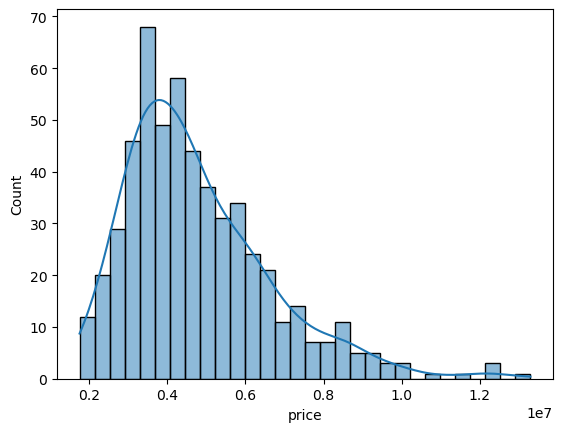

In [ ]:
sns.histplot(df["price"], bins=30, kde=True)
plt.show()
#Visualized the distribution of house prices using a histogram.

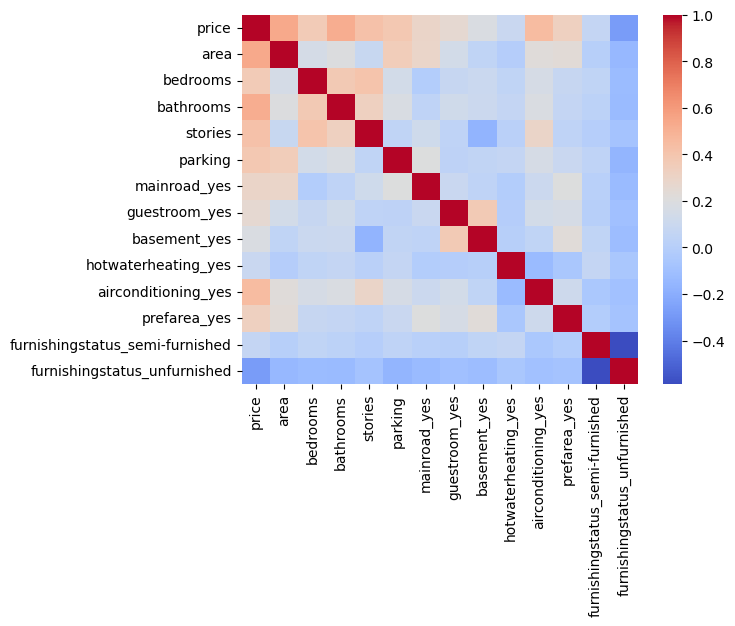

In [ ]:
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()
#Displayed the correlation matrix to understand relationships among variables.

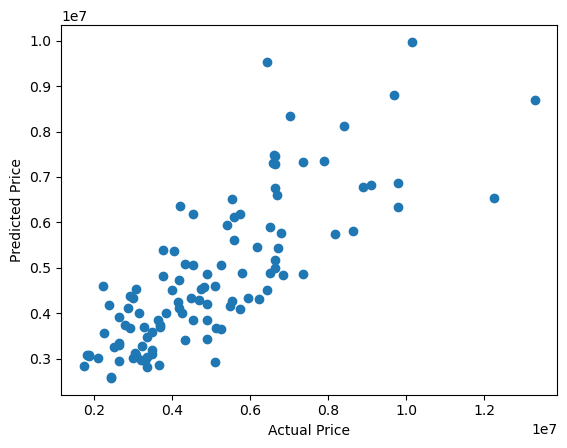

In [ ]:
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()
#Compared actual house prices with predicted prices to assess model accuracy.

In [23]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)
#Identified the most important features influencing house prices.

,Feature,Importance
0,area,0.468430
2,bathrooms,0.151483
9,airconditioning_yes,0.062672
4,parking,0.057455
3,stories,0.057133
1,bedrooms,0.048413
12,furnishingstatus_unfurnished,0.035011
7,basement_yes,0.030823
10,prefarea_yes,0.030689
8,hotwaterheating_yes,0.017226


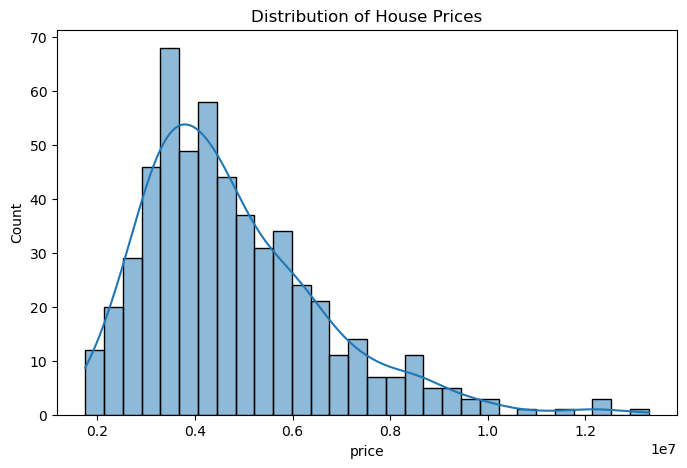

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=30, kde=True)
plt.title("Distribution of House Prices")

plt.savefig("charts/histogram.png")

plt.show()

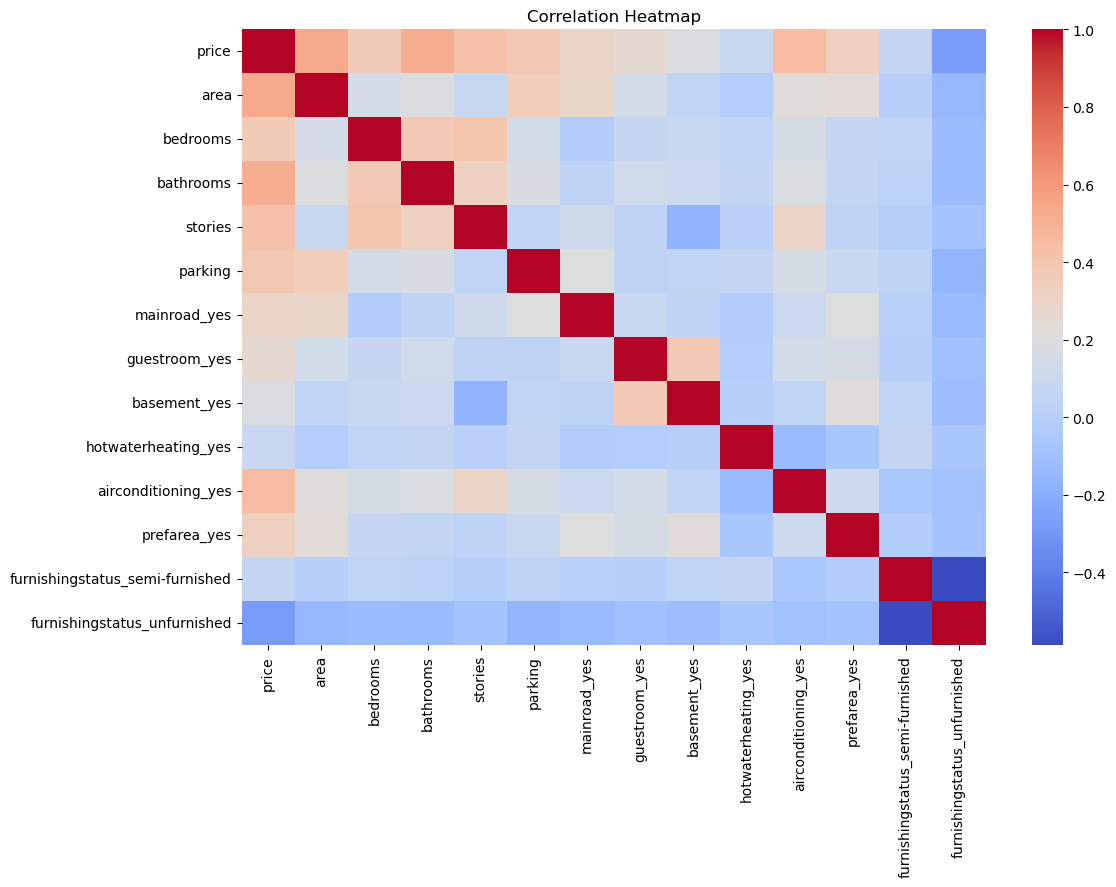

In [26]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.savefig("charts/heatmap.png")

plt.show()

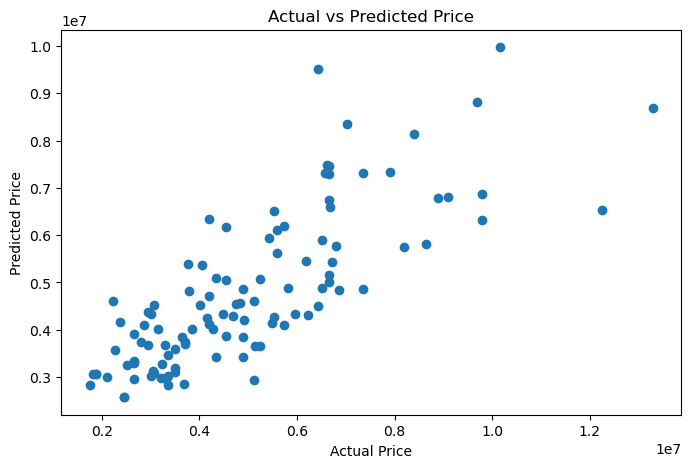

In [27]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")

plt.savefig("charts/scatter.png")

plt.show()

In [28]:
print("Linear Regression")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

print("\nRandom Forest")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

Linear Regression
MAE: 970043.4039201641
RMSE: 1324506.9600914388
R2: 0.6529242642153182

Random Forest
MAE: 1021546.0353211008
RMSE: 1400565.9728553821
R2: 0.611918531405699


In [ ]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, mae_rf],
    "RMSE": [rmse, rmse_rf],
    "R2 Score": [r2, r2_rf]
})

comparison
#Compared the performance of Linear Regression and Random Forest models using evaluation metrics.

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919
